MSE: 2.3940209427865526
R²: 0.8424628390289359


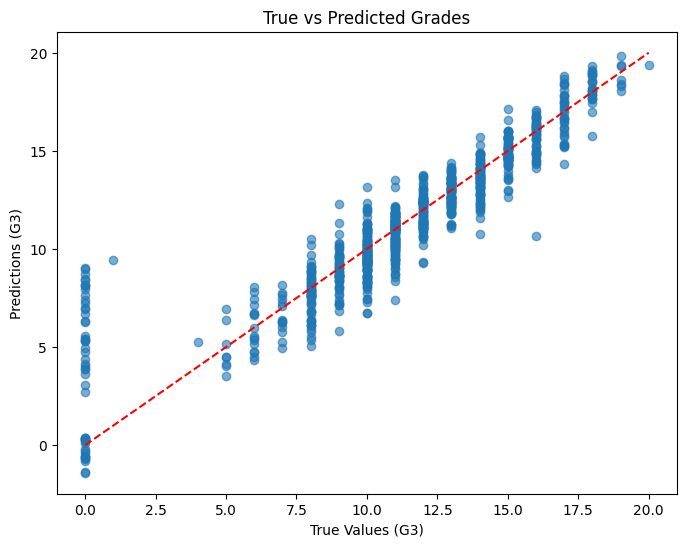

In [5]:
import joblib
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 加载模型
model = joblib.load("E:/TPU_Work/jidian_shujufenxi/tpu_8EM41_ML_course/models/model.pkl")

# 加载数据
df = pd.read_csv("data/student_combined_cleaned.csv")

# 特征和目标
X = df.drop(columns=['G3'])
y = df['G3']

# 对分类特征进行独热编码，确保和训练数据的特征一致
X = pd.get_dummies(X)

# 使测试数据与训练数据的特征一致，填补缺失的列（如果有），并用0填充
X = X.reindex(columns=model.feature_names_in_, fill_value=0)

# 预测
y_pred = model.predict(X)

# 评估
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

# 打印评估结果
print("MSE:", mse)
print("R²:", r2)

# 可视化预测结果
plt.figure(figsize=(8,6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([0, 20], [0, 20], color='red', linestyle='--')  # 绘制理想的完美拟合线
plt.xlabel("True Values (G3)")
plt.ylabel("Predictions (G3)")
plt.title("True vs Predicted Grades")
plt.show()